# Model 2 — Task time estimation · result sheet

All logic lives in `ml/task_time/train.py` (`python -m ml.task_time.train` trains from the CLI); this notebook imports it and only presents results.

Pipeline per docs/models.md §2: time split by task_date (train 1–70, validation 71–80, test 81–90), standard p50 quantile LightGBM → OOF `standard_min` (GroupKFold by ISO week) → personal p10/p50/p90 → split-conformal widening → test metrics → SHAP. `tasks_truth.csv` is used **only** to check that the learned effects match the hidden formula — never for training.

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from ml.task_time.train import load_results, metrics_table, train_all

In [2]:
# Load the saved run (train via CLI: python -m ml.task_time.train), or train here if absent.
try:
    res = load_results()
except FileNotFoundError:
    res = train_all()
print("artifacts:", res["out_dir"])

artifacts: /Users/sohammahapatra/Work/SchoolBus/ml/artifacts/task_time/v1


## Metrics (test days 81–90)

Personal p50 must beat the median-per-unit baseline; final p10–p90 coverage must be 75–85%.

In [3]:
display(metrics_table(res))
m = res["metrics"]
off = (
    f"offset {m['conformal_offset_min']:.1f} min applied"
    if m["conformal_applied"]
    else "not needed"
)
print(
    f"p10–p90 coverage (test): {m['coverage_test']:.3f}  (validation raw {m['coverage_val_raw']:.3f}, conformal {off})"
)
assert m["personal_beats_baseline"] and 0.75 <= m["coverage_test"] <= 0.85

,model,MAE_min,MAPE
0,personal p50,7.873211,0.093190
1,standard p50,11.273711,0.134606
2,baseline (median min/unit x qty),24.370739,0.297080


p10–p90 coverage (test): 0.793  (validation raw 0.657, conformal offset 2.8 min applied)


## What the model uses

Top features by mean |SHAP| — quantity dominates; operator features (personal model) add the behavioural signal.

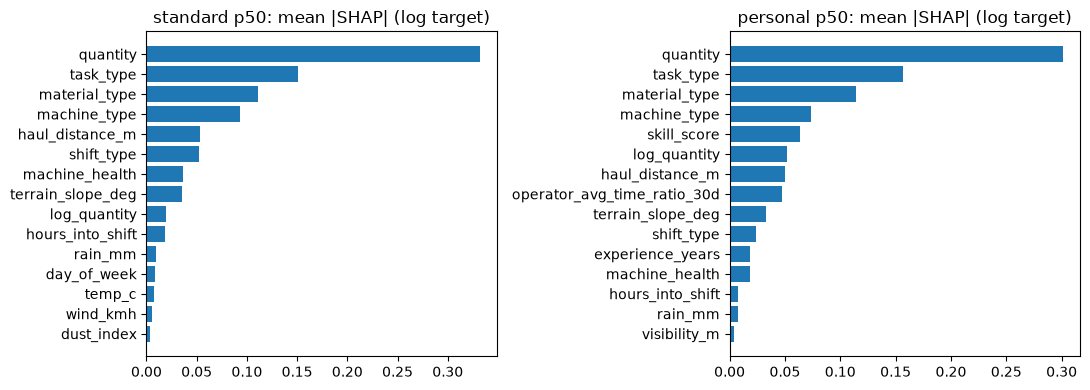

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (title, key) in zip(axes, [("standard p50", "standard"), ("personal p50", "personal")]):
    top = res["shap_top"][key].iloc[::-1]
    ax.barh(top["feature"], top["mean_abs_shap"])
    ax.set_title(f"{title}: mean |SHAP| (log target)")
fig.tight_layout()

## Learned effects vs the hidden formula

The generator buried a hidden duration formula (rain ×1+0.015·mm, slope ×1+0.02·deg, rock ×1.4, night ×1.1, skill ×1.25−0.5·skill). `tasks_truth.csv` carries the factors and is used **only here** to check the model recovered them.

In [5]:
effects = res["effects"].copy()
effects["learned_pct"] = (effects["learned"] * 100).round(1)
effects["hidden_pct"] = (effects["hidden"] * 100).round(1)
display(effects[["effect", "learned_pct", "hidden_pct", "expected_direction", "direction_ok"]])
assert effects["direction_ok"].all(), "learned effect in the wrong direction"
print("all learned effects match the hidden formula in sign and rough magnitude")

,effect,learned_pct,hidden_pct,expected_direction,direction_ok
0,rain: % when raining,4.4,5.8,+,True
1,slope: log per deg,1.7,1.8,+,True
2,rock vs clay: %,36.9,40.0,+,True
3,night: %,5.3,10.0,+,True
4,skill: log per skill point (personal),-42.4,-55.5,-,True


all learned effects match the hidden formula in sign and rough magnitude


## Calibration on the test days

Predictions vs actuals, with the conformal-widened p10–p90 interval.

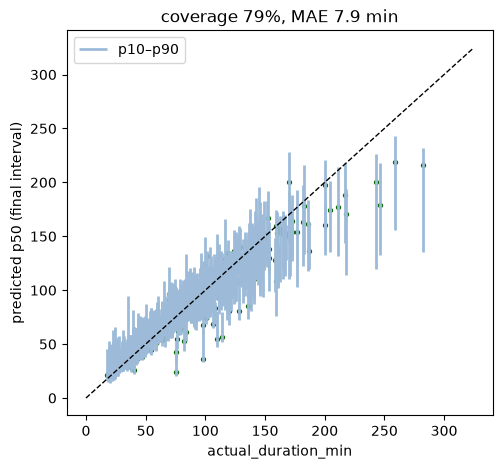

In [6]:
p = res["test_predictions"]
fig, ax = plt.subplots(figsize=(5.5, 5))
sample = p.sample(min(600, len(p)), random_state=42)
ax.vlines(
    sample["actual_duration_min"],
    sample["final_p10_min"],
    sample["final_p90_min"],
    color="#9dbbd8",
    lw=2,
    label="p10–p90",
)
ax.scatter(sample["actual_duration_min"], sample["personal_p50_min"], s=8, color="#0a6b0a")
lim = (0, sample["actual_duration_min"].max() * 1.15)
ax.plot(lim, lim, "k--", lw=1)
ax.set(
    xlabel="actual_duration_min",
    ylabel="predicted p50 (final interval)",
    title=f"coverage {m['coverage_test']:.0%}, MAE {m['personal_mae_min']:.1f} min",
)
ax.legend()